# BUSINFO 701 Technical Report: Tobacco Policy, Smoking Behaviour, and Lung Cancer Mortality

## Technical objective

This notebook prepares the technical part of the group assignment. The goal is to construct one clean **state-year analytical dataset** that combines cigarette excise tax, cigarette consumption, adult smoking prevalence, and lung cancer mortality data.

The final dataset uses this structure:

- one row = one U.S. state or District of Columbia in one year
- merge keys = `state_name` and `Year`
- final output = `output/combined_tobacco_panel.csv`

The notebook is organised into the required technical-report sections:

1. Data wrangling  
2. Questions and analysis  
3. Limitations and web scraping

## Section 1 — Data Wrangling

This section loads the four data sources, audits their structure, cleans each dataset separately, standardises the merge keys, combines them into one state-year dataset, creates derived variables, and saves the final data store.

In [1]:
# Package imports and folder setup
!pip install pandas numpy matplotlib requests beautifulsoup4
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import requests
from bs4 import BeautifulSoup

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)

DATA_DIR = Path("data")
OUTPUT_DIR = Path("output")
FIGURE_DIR = Path("figures")

DATA_DIR.mkdir(exist_ok=True)
OUTPUT_DIR.mkdir(exist_ok=True)
FIGURE_DIR.mkdir(exist_ok=True)

print("Folders ready:")
print("Data folder:", DATA_DIR.resolve())
print("Output folder:", OUTPUT_DIR.resolve())
print("Figures folder:", FIGURE_DIR.resolve())

Folders ready:
Data folder: D:\CourseUoA\Q2_2026\BUSINFO701\GroupProject\data
Output folder: D:\CourseUoA\Q2_2026\BUSINFO701\GroupProject\output
Figures folder: D:\CourseUoA\Q2_2026\BUSINFO701\GroupProject\figures


### 1.1 Data source links and local filenames

The notebook uses the following local files. These files should be saved in the `data` folder.

| Dataset | Source | Years | Format | Key Columns | Role in Project |
|---|---|---|---|---|---|
| CDC STATE System — Excise Tax | [CDC data.gov](https://data.cdc.gov/Legislation/CDC-STATE-System-Tobacco-Legislation-Tax/2dwv-vfam) | 1995–2027 | CSV, 211,659 rows × 23 cols | `LocationDesc`, `Year`, `ProvisionAltValue` | Policy input variable — captures state-level cigarette tax per pack over time |
| Cigarette Consumption Per Capita (Orzechowski & Walker) | [CDC data.gov](https://data.cdc.gov/Policy/Map-of-Cigarette-Consumption-Per-Capita-Orzechowsk/hdg8-p5wc/about) | 1970–2019 | CSV, 15,300 rows × 17 cols | `LocationDesc`, `Year`, `Data_Value` | Behavioural outcome — measures actual pack sales per capita by state |
| BRFSS Adult Smoking Prevalence | [CDC BRFSS](https://www.cdc.gov/brfss/brfssprevalence/index.html) | 1995–2010 | CSV, 875 rows × 6 cols | `State`, `Year`, `Yes` | Behavioural outcome — percentage of adults who are current smokers by state |
| Lung Cancer Mortality (CDC WONDER / USCS) | [CDC WONDER](https://wonder.cdc.gov/cancer.html) | 1999–2021 | CSV, 1,218 rows × 10 cols | `State`, `Year`, `Age-Adjusted Rate` | Health outcome — age-adjusted lung and bronchus cancer mortality rate by state |

All four datasets are state-year structured, produced by U.S. federal agencies, and publicly accessible. The common merge keys `state_name` and `Year` allow them to be joined into a single panel. The excise tax dataset required filtering from 211,659 raw rows to cigarette-specific records only. The consumption dataset covers the longest time span (1970–2019) but ends before the mortality series (1999–2021), creating a partial overlap window used in the analysis.

In [2]:
# Load raw datasets from the local data folder

tax_raw = pd.read_csv(DATA_DIR / "excise_tax.csv", low_memory=False)
cons_raw = pd.read_csv(DATA_DIR / "cigarette_consumption.csv", low_memory=False)
brfss_raw = pd.read_csv(DATA_DIR / "brfss_smoking.csv")
mort_raw = pd.read_csv(DATA_DIR / "lung_mortality.csv")

raw_summary = pd.DataFrame({
    "dataset": ["Excise tax", "Cigarette consumption", "BRFSS smoking", "Lung cancer mortality"],
    "rows": [len(tax_raw), len(cons_raw), len(brfss_raw), len(mort_raw)],
    "columns": [tax_raw.shape[1], cons_raw.shape[1], brfss_raw.shape[1], mort_raw.shape[1]]
})

raw_summary

,dataset,rows,columns
0,Excise tax,211659,23
1,Cigarette consumption,15300,17
2,BRFSS smoking,875,6
3,Lung cancer mortality,1218,10


In [3]:
# Initial audit: show column names for each raw dataset

for name, df in {
    "Excise tax": tax_raw,
    "Cigarette consumption": cons_raw,
    "BRFSS smoking": brfss_raw,
    "Lung cancer mortality": mort_raw
}.items():
    print("\n" + "=" * 80)
    print(name)
    print("Rows, columns:", df.shape)
    print("Columns:")
    print(list(df.columns))


Excise tax
Rows, columns: (211659, 23)
Columns:
['Year', 'Quarter', 'LocationAbbr', 'LocationDesc', 'TopicDesc', 'MeasureDesc', 'DataSource', 'ProvisionGroupDesc', 'ProvisionDesc', 'ProvisionValue', 'Citation', 'ProvisionAltValue', 'DataType', 'Comments', 'Enacted_Date', 'Effective_Date', 'GeoLocation', 'DisplayOrder', 'TopicTypeId', 'TopicId', 'MeasureId', 'ProvisionGroupID', 'ProvisionID']

Cigarette consumption
Rows, columns: (15300, 17)
Columns:
['LocationAbbr', 'LocationDesc', 'Year', 'Datasource', 'TopicDesc', 'MeasureDesc', 'SubMeasureDesc', 'Data_Value', 'Data_Value_Unit', 'Data_Value_Type', 'GeoLocation', 'Source', 'TopicTypeId', 'TopicId', 'MeasureId', 'SubMeasureID', 'SubMeasureIdDisplayOrder']

BRFSS smoking
Rows, columns: (875, 6)
Columns:
['Year', 'State', 'Condition', 'Yes', 'No', 'Location 1']

Lung cancer mortality
Rows, columns: (1218, 10)
Columns:
['Notes', 'Cancer Sites', 'Cancer Sites Code', 'State', 'State Code', 'Year', 'Year Code', 'Deaths', 'Population', 'Age-

### 1.2 State filter used for consistency

The final dataset is limited to the 50 U.S. states plus the District of Columbia. This prevents territories and national aggregate rows from causing failed joins or misleading comparisons.

In [4]:
US_STATES_DC = [
    "Alabama", "Alaska", "Arizona", "Arkansas", "California", "Colorado", "Connecticut", "Delaware",
    "District of Columbia", "Florida", "Georgia", "Hawaii", "Idaho", "Illinois", "Indiana", "Iowa",
    "Kansas", "Kentucky", "Louisiana", "Maine", "Maryland", "Massachusetts", "Michigan", "Minnesota",
    "Mississippi", "Missouri", "Montana", "Nebraska", "Nevada", "New Hampshire", "New Jersey",
    "New Mexico", "New York", "North Carolina", "North Dakota", "Ohio", "Oklahoma", "Oregon",
    "Pennsylvania", "Rhode Island", "South Carolina", "South Dakota", "Tennessee", "Texas", "Utah",
    "Vermont", "Virginia", "Washington", "West Virginia", "Wisconsin", "Wyoming"
]

def clean_percent(value):
    """Convert percentage values such as '21.5%' into numeric values such as 21.5."""
    if pd.isna(value):
        return np.nan
    return pd.to_numeric(str(value).replace("%", "").strip(), errors="coerce")

def audit_clean_dataset(name, df, key_cols):
    """Create a compact audit table for a cleaned dataset."""
    duplicate_count = df.duplicated(subset=key_cols).sum()
    return pd.DataFrame({
        "dataset": [name],
        "rows": [len(df)],
        "columns": [df.shape[1]],
        "unique_states": [df["state_name"].nunique() if "state_name" in df.columns else np.nan],
        "min_year": [df["Year"].min() if "Year" in df.columns else np.nan],
        "max_year": [df["Year"].max() if "Year" in df.columns else np.nan],
        "duplicate_key_rows": [duplicate_count]
    })

### 1.3 Dataset A: CDC STATE System cigarette excise tax

**Origin:** CDC STATE System Tobacco Legislation database, accessed via data.cdc.gov. This is the primary policy variable for the project.

**General characteristics:** 211,659 rows × 23 columns. Covers multiple tobacco product types, multiple legislative provisions, and quarterly records from 1995 to 2027 across all U.S. states and territories.

**Initial audit observations:**
- The file contains multiple tobacco product types (cigarettes, pipe tobacco, snuff, etc.) — only cigarette-specific rows are relevant
- Tax values are split across two columns (`ProvisionValue` and `ProvisionAltValue`) requiring consolidation
- Records include future years (2027) and territories outside the 50 states + DC
- Multiple quarterly records exist per state-year — only the latest quarter is needed

**Transformations applied before combining:**
1. Filtered to rows where `MeasureDesc` = "Cigarette" and `ProvisionDesc` = "Cigarette Tax ($ per pack)"
2. Standardised state names from `LocationDesc`, stripped whitespace
3. Converted `Year` and `Quarter` to integer
4. Extracted numeric tax value from `ProvisionAltValue`, falling back to `ProvisionValue` where needed
5. Restricted to 50 U.S. states and District of Columbia only
6. Filtered to years 1995–2024
7. Removed duplicate state-year rows by keeping the latest available quarter
8. Retained only `state_name`, `Year`, `excise_tax`

In [5]:
tax = tax_raw.copy()

tax = tax[
    (tax["MeasureDesc"].astype(str).str.strip() == "Cigarette") &
    (tax["ProvisionDesc"].astype(str).str.strip() == "Cigarette Tax ($ per pack)")
].copy()

tax["state_name"] = tax["LocationDesc"].astype(str).str.strip()
tax["Year"] = pd.to_numeric(tax["Year"], errors="coerce").astype("Int64")
tax["Quarter"] = pd.to_numeric(tax["Quarter"], errors="coerce").astype("Int64")

tax["excise_tax"] = pd.to_numeric(tax["ProvisionAltValue"], errors="coerce")
tax["excise_tax"] = tax["excise_tax"].fillna(
    pd.to_numeric(tax["ProvisionValue"].replace("No Provision", np.nan), errors="coerce")
)

tax = tax[tax["state_name"].isin(US_STATES_DC)].copy()
tax = tax[tax["Year"].between(1995, 2024)].copy()

# Use the latest available quarter in each state-year.
tax_clean = (
    tax.dropna(subset=["state_name", "Year", "Quarter", "excise_tax"])
       .sort_values(["state_name", "Year", "Quarter"])
       .drop_duplicates(subset=["state_name", "Year"], keep="last")
       [["state_name", "Year", "excise_tax"]]
       .reset_index(drop=True)
)

audit_clean_dataset("Clean excise tax", tax_clean, ["state_name", "Year"])

,dataset,rows,columns,unique_states,min_year,max_year,duplicate_key_rows
0,Clean excise tax,1530,3,51,1995,2024,0


In [6]:
tax_clean.head()

,state_name,Year,excise_tax
0,Alabama,1995,0.165
1,Alabama,1996,0.165
2,Alabama,1997,0.165
3,Alabama,1998,0.165
4,Alabama,1999,0.165


### 1.4 Dataset B: Orzechowski & Walker cigarette consumption per capita

**Origin:** CDC data portal, sourced from the Orzechowski & Walker Tax Burden on Tobacco publication. This dataset captures actual cigarette purchasing behaviour at state level.

**General characteristics:** 15,300 rows × 17 columns. Contains multiple tobacco-related measures including average cost per pack, gross tax revenue, and consumption per capita. Covers 1970–2019.

**Initial audit observations:**
- Multiple measures are stored in a single `SubMeasureDesc` column — only consumption per capita rows are relevant
- The `Data_Value` column contains numeric values stored as strings requiring conversion
- Dataset ends in 2019, creating a gap relative to the mortality series which runs to 2021

**Transformations applied before combining:**
1. Filtered to rows where `SubMeasureDesc` contains "Cigarette Consumption"
2. Standardised state names from `LocationDesc`, stripped whitespace
3. Converted `Year` to integer
4. Converted `Data_Value` to numeric as `consumption_per_capita`
5. Restricted to 50 U.S. states and District of Columbia only
6. Removed duplicate state-year rows, keeping last available record
7. Retained only `state_name`, `Year`, `consumption_per_capita`

In [7]:
cons = cons_raw.copy()

cons = cons[
    cons["SubMeasureDesc"].astype(str).str.contains("Cigarette Consumption", case=False, na=False)
].copy()

cons["state_name"] = cons["LocationDesc"].astype(str).str.strip()
cons["Year"] = pd.to_numeric(cons["Year"], errors="coerce").astype("Int64")
cons["consumption_per_capita"] = pd.to_numeric(cons["Data_Value"], errors="coerce")

cons = cons[cons["state_name"].isin(US_STATES_DC)].copy()

cons_clean = (
    cons.dropna(subset=["state_name", "Year", "consumption_per_capita"])
        .drop_duplicates(subset=["state_name", "Year"], keep="last")
        [["state_name", "Year", "consumption_per_capita"]]
        .reset_index(drop=True)
)

audit_clean_dataset("Clean cigarette consumption", cons_clean, ["state_name", "Year"])

,dataset,rows,columns,unique_states,min_year,max_year,duplicate_key_rows
0,Clean cigarette consumption,2550,3,51,1970,2019,0


In [8]:
cons_clean.head()

,state_name,Year,consumption_per_capita
0,Alabama,2019,53.1
1,Alaska,2019,30.4
2,Arizona,2019,20.7
3,Arkansas,2019,47.6
4,California,2019,15.8


### 1.5 Dataset C: BRFSS adult smoking prevalence

**Origin:** CDC Behavioral Risk Factor Surveillance System (BRFSS), prevalence tables. This dataset captures self-reported adult smoking behaviour at state level.

**General characteristics:** 875 rows × 6 columns. Contains the percentage of adults who are current smokers by state and year. This extract covers 1995–2010.

**Initial audit observations:**
- The `Yes` column stores prevalence as percentage strings (e.g., "21.5%") requiring conversion to numeric
- The file includes U.S. territories (Guam, Virgin Islands, Puerto Rico, and nationwide aggregate rows) which must be excluded
- Coverage ends in 2010 — this is a deliberate methodological choice to enable the 10–20 year latency analysis in Q2, linking earlier smoking behaviour to later mortality outcomes
- No missing values present in the raw file

**Transformations applied before combining:**
1. Standardised state names from `State` column, stripped whitespace
2. Converted `Year` to integer
3. Filtered to rows where `Condition` contains "current smokers"
4. Converted `Yes` percentage strings to numeric using a custom `clean_percent()` function
5. Restricted to 50 U.S. states and District of Columbia only
6. Removed duplicate state-year rows, keeping last available record
7. Retained only `state_name`, `Year`, `smoking_prevalence`

In [9]:
brfss = brfss_raw.copy()

brfss["state_name"] = brfss["State"].astype(str).str.strip()
brfss["Year"] = pd.to_numeric(brfss["Year"], errors="coerce").astype("Int64")

if "Condition" in brfss.columns:
    brfss = brfss[
        brfss["Condition"].astype(str).str.contains("current smokers", case=False, na=False)
    ].copy()

brfss["smoking_prevalence"] = brfss["Yes"].apply(clean_percent)

brfss = brfss[brfss["state_name"].isin(US_STATES_DC)].copy()

brfss_clean = (
    brfss.dropna(subset=["state_name", "Year", "smoking_prevalence"])
         .drop_duplicates(subset=["state_name", "Year"], keep="last")
         [["state_name", "Year", "smoking_prevalence"]]
         .reset_index(drop=True)
)

audit_clean_dataset("Clean BRFSS smoking prevalence", brfss_clean, ["state_name", "Year"])

,dataset,rows,columns,unique_states,min_year,max_year,duplicate_key_rows
0,Clean BRFSS smoking prevalence,812,3,51,1995,2010,0


In [10]:
brfss_clean.head()

,state_name,Year,smoking_prevalence
0,Kansas,2007,17.9
1,Idaho,2008,16.9
2,Arkansas,2007,22.4
3,Alabama,2004,24.9
4,Tennessee,1997,26.9


### 1.6 Dataset D: Lung cancer mortality (CDC WONDER / USCS)

**Origin:** United States Cancer Statistics (USCS) mortality data via CDC WONDER. This dataset captures the health outcome at the end of the policy chain: tax → behaviour → mortality.

**General characteristics:** 1,218 rows × 10 columns. Contains lung and bronchus cancer death counts, population figures, and age-adjusted mortality rates by state and year. Covers 1999–2021 across all 51 jurisdictions (50 states + DC).

**Initial audit observations:**
- The file contains 45 rows of CDC WONDER query metadata appended at the bottom (citations, query parameters, caveats) — these rows have null State and Year values and are automatically excluded by the state filter
- Age-adjusted rate is used rather than raw death counts because it allows fair comparison across states with different population sizes and age structures
- All 1,173 expected state-year records (51 jurisdictions × 23 years) are present — no suppression or export gaps

**Transformations applied before combining:**
1. Filtered to rows where `Cancer Sites` contains "Lung and Bronchus"
2. Standardised state names from `State` column, stripped whitespace
3. Converted `Year` to integer
4. Converted `Age-Adjusted Rate` to numeric as `lung_cancer_rate`
5. Converted `Deaths` and `Population` to numeric
6. Restricted to 50 U.S. states and District of Columbia only
7. Removed duplicate state-year rows, keeping last available record
8. Retained only `state_name`, `Year`, `lung_cancer_rate`, `lung_cancer_deaths`, `population`

In [11]:
mort = mort_raw.copy()

mort = mort[
    mort["Cancer Sites"].astype(str).str.contains("Lung and Bronchus", case=False, na=False)
].copy()

mort["state_name"] = mort["State"].astype(str).str.strip()
mort["Year"] = pd.to_numeric(mort["Year"], errors="coerce").astype("Int64")
mort["lung_cancer_rate"] = pd.to_numeric(mort["Age-Adjusted Rate"], errors="coerce")
mort["lung_cancer_deaths"] = pd.to_numeric(mort["Deaths"], errors="coerce")
mort["population"] = pd.to_numeric(mort["Population"], errors="coerce")

mort = mort[mort["state_name"].isin(US_STATES_DC)].copy()

mort_clean = (
    mort.dropna(subset=["state_name", "Year", "lung_cancer_rate"])
        .drop_duplicates(subset=["state_name", "Year"], keep="last")
        [["state_name", "Year", "lung_cancer_rate", "lung_cancer_deaths", "population"]]
        .reset_index(drop=True)
)

audit_clean_dataset("Clean lung cancer mortality", mort_clean, ["state_name", "Year"])

,dataset,rows,columns,unique_states,min_year,max_year,duplicate_key_rows
0,Clean lung cancer mortality,1173,5,51,1999,2021,0


In [12]:
mort_clean.head()

,state_name,Year,lung_cancer_rate,lung_cancer_deaths,population
0,Alabama,1999,62.5,2852.0,4430141.0
1,Alabama,2000,64.2,2964.0,4452173.0
2,Alabama,2001,62.6,2912.0,4467634.0
3,Alabama,2002,63.5,2989.0,4480089.0
4,Alabama,2003,65.0,3107.0,4503491.0


### 1.7 Combine datasets into one state-year panel

All datasets are joined using `state_name` and `Year`. An outer merge is used so that available data from different periods is preserved. This is appropriate because the four sources do not cover exactly the same year range.

In [13]:
combined = tax_clean.merge(cons_clean, on=["state_name", "Year"], how="outer")
combined = combined.merge(brfss_clean, on=["state_name", "Year"], how="outer")
combined = combined.merge(mort_clean, on=["state_name", "Year"], how="outer")

combined = combined[combined["state_name"].isin(US_STATES_DC)].copy()
combined["Year"] = combined["Year"].astype(int)
combined = combined.sort_values(["state_name", "Year"]).reset_index(drop=True)

print("Combined dataset shape:", combined.shape)
combined.head()

Combined dataset shape: (2805, 8)


,state_name,Year,excise_tax,consumption_per_capita,smoking_prevalence,lung_cancer_rate,lung_cancer_deaths,population
0,Alabama,1970,NaN,89.8,NaN,NaN,NaN,NaN
1,Alabama,1971,NaN,95.4,NaN,NaN,NaN,NaN
2,Alabama,1972,NaN,101.1,NaN,NaN,NaN,NaN
3,Alabama,1973,NaN,102.9,NaN,NaN,NaN,NaN
4,Alabama,1974,NaN,108.2,NaN,NaN,NaN,NaN


### 1.8 Feature engineering

The following analysis-ready variables are created:

- year-on-year change in tax
- year-on-year change in consumption
- year-on-year change in smoking prevalence
- year-on-year change in lung cancer mortality
- next-year consumption change for Q1
- 10-year, 15-year, and 20-year lagged smoking prevalence for Q2

In [14]:
combined["tax_change"] = combined.groupby("state_name")["excise_tax"].diff()
combined["consumption_change"] = combined.groupby("state_name")["consumption_per_capita"].diff()
combined["smoking_prevalence_change"] = combined.groupby("state_name")["smoking_prevalence"].diff()
combined["mortality_change"] = combined.groupby("state_name")["lung_cancer_rate"].diff()

combined["next_consumption_change"] = (
    combined.groupby("state_name")["consumption_per_capita"].shift(-1) -
    combined["consumption_per_capita"]
)

for lag in [10, 15, 20]:
    combined[f"smoking_prevalence_lag_{lag}"] = (
        combined.groupby("state_name")["smoking_prevalence"].shift(lag)
    )

combined.head()

,state_name,Year,excise_tax,consumption_per_capita,smoking_prevalence,lung_cancer_rate,lung_cancer_deaths,population,tax_change,consumption_change,smoking_prevalence_change,mortality_change,next_consumption_change,smoking_prevalence_lag_10,smoking_prevalence_lag_15,smoking_prevalence_lag_20
0,Alabama,1970,NaN,89.8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.6,NaN,NaN,NaN
1,Alabama,1971,NaN,95.4,NaN,NaN,NaN,NaN,NaN,5.6,NaN,NaN,5.7,NaN,NaN,NaN
2,Alabama,1972,NaN,101.1,NaN,NaN,NaN,NaN,NaN,5.7,NaN,NaN,1.8,NaN,NaN,NaN
3,Alabama,1973,NaN,102.9,NaN,NaN,NaN,NaN,NaN,1.8,NaN,NaN,5.3,NaN,NaN,NaN
4,Alabama,1974,NaN,108.2,NaN,NaN,NaN,NaN,NaN,5.3,NaN,NaN,3.5,NaN,NaN,NaN


### 1.9 Final validation table

The final validation table checks the row count, state count, year range, duplicate keys, and missing values. Missing values are expected because the source datasets cover different time periods.

In [15]:
# Final validation checks for the merged state-year panel

mortality_year_count = mort_clean["Year"].nunique()
expected_mortality_pairs = len(US_STATES_DC) * mortality_year_count
actual_mortality_pairs = mort_clean[["state_name", "Year"]].drop_duplicates().shape[0]
mortality_pairs_lost = expected_mortality_pairs - actual_mortality_pairs

validation_summary = pd.DataFrame({
    "check": [
        "Total rows in combined working dataset",
        "Unique states",
        "Minimum year",
        "Maximum year",
        "Duplicate state-year rows",
        "Missing tax values",
        "Missing consumption values",
        "Missing smoking prevalence values",
        "Missing lung cancer mortality values",
        "Expected mortality state-year rows",
        "Available mortality state-year rows",
        "Mortality state-year rows lost to suppression/export filtering"
    ],
    "result": [
        len(combined),
        combined["state_name"].nunique(),
        combined["Year"].min(),
        combined["Year"].max(),
        combined.duplicated(subset=["state_name", "Year"]).sum(),
        combined["excise_tax"].isna().sum(),
        combined["consumption_per_capita"].isna().sum(),
        combined["smoking_prevalence"].isna().sum(),
        combined["lung_cancer_rate"].isna().sum(),
        expected_mortality_pairs,
        actual_mortality_pairs,
        mortality_pairs_lost
    ]
})

validation_summary

,check,result
0,Total rows in combined working dataset,2805
1,Unique states,51
2,Minimum year,1970
3,Maximum year,2024
4,Duplicate state-year rows,0
5,Missing tax values,1275
6,Missing consumption values,255
7,Missing smoking prevalence values,1993
8,Missing lung cancer mortality values,1632
9,Expected mortality state-year rows,1173


### 1.10 Final combined dataset data dictionary

The final data store is intentionally kept to the core analysis-ready fields needed for the group questions.

| Column | Description |
|---|---|
| `state_name` | U.S. state or District of Columbia |
| `Year` | Calendar year |
| `excise_tax` | Cigarette excise tax in dollars per pack |
| `consumption_per_capita` | Cigarette pack sales per capita |
| `smoking_prevalence` | Percentage of adults who are current smokers |
| `lung_cancer_rate` | Lung and bronchus cancer age-adjusted mortality rate |
| `tax_change` | Year-on-year change in cigarette excise tax |
| `consumption_change` | Year-on-year change in cigarette consumption per capita |
| `smoking_prevalence_change` | Year-on-year change in adult smoking prevalence |
| `mortality_change` | Year-on-year change in lung cancer mortality rate |
| `smoking_prevalence_lag_10` | Smoking prevalence from 10 years earlier |
| `smoking_prevalence_lag_15` | Smoking prevalence from 15 years earlier |
| `smoking_prevalence_lag_20` | Smoking prevalence from 20 years earlier |

In [16]:
# Save the final combined data store and validation summary

final_columns = [
    "state_name", "Year", "excise_tax", "consumption_per_capita", "smoking_prevalence", "lung_cancer_rate",
    "tax_change", "consumption_change", "smoking_prevalence_change", "mortality_change",
    "smoking_prevalence_lag_10", "smoking_prevalence_lag_15", "smoking_prevalence_lag_20"
]

final_combined = combined[final_columns].copy()

final_combined.to_csv(OUTPUT_DIR / "combined_tobacco_panel.csv", index=False)
validation_summary.to_csv(OUTPUT_DIR / "final_validation_summary.csv", index=False)

print("Saved final combined dataset to:", OUTPUT_DIR / "combined_tobacco_panel.csv")
print("Final combined dataset shape:", final_combined.shape)
print("Saved validation summary to:", OUTPUT_DIR / "final_validation_summary.csv")

Saved final combined dataset to: output\combined_tobacco_panel.csv
Final combined dataset shape: (2805, 13)
Saved validation summary to: output\final_validation_summary.csv


### Final data store note

The local final data store produced by this notebook is:

`output/combined_tobacco_panel.csv`

**Final combined data store link:** [combined_tobacco_panel.csv](https://drive.google.com/file/d/1tn2A8ZhH8nLTYhDlAPJzUQHu094xD10I/view?usp=sharing)

This link is required because the assignment asks for the final combined data store to be accessible for inspection.

## Section 2 — Questions and Analysis

### Q1 — Does a higher state cigarette excise tax lead to lower per-capita cigarette consumption?

This question uses the merged excise tax and cigarette consumption fields. Two checks are used:

1. same-year relationship between tax and consumption
2. relationship between tax increases and next-year consumption changes

**Method:** Pearson correlation and ordinary least squares regression, applied to the merged excise tax and cigarette consumption fields. Two models are used: (1) a same-year model testing the static relationship between tax level and consumption level, and (2) a tax-change model testing whether a tax increase in one year predicts a consumption decline in the following year. OLS regression is appropriate here because both variables are continuous and the goal is to estimate the magnitude of association, not just its direction.

**Steps:**
1. Filtered the combined dataset to rows where both `excise_tax` and `consumption_per_capita` are non-null
2. Computed Pearson correlation and OLS slope for the same-year tax-consumption relationship
3. Isolated state-years where a non-zero tax change occurred
4. Computed Pearson correlation and OLS slope between tax change and next-year consumption change
5. Scaled the per-capita estimate to a median-state population figure for policy interpretability
6. Visualised the same-year relationship with a scatter plot and regression line

**Answer:** Higher cigarette excise taxes are clearly associated with lower per-capita consumption. The same-year correlation is -0.658 and the estimated slope is -22.04 packs per $1 of additional tax. The forward-looking tax-change model is weaker (-0.145 correlation) but confirms the direction: a $1 tax increase is associated with approximately 3.56 fewer packs per capita in the following year, equivalent to roughly 15 million fewer packs for a median-sized state.

In [17]:
q1 = combined.dropna(subset=["excise_tax", "consumption_per_capita"]).copy()

q1_corr = q1["excise_tax"].corr(q1["consumption_per_capita"])
q1_slope, q1_intercept = np.polyfit(q1["excise_tax"], q1["consumption_per_capita"], 1)

q1_change = combined.dropna(subset=["tax_change", "next_consumption_change"]).copy()
q1_change = q1_change[q1_change["tax_change"] != 0]

q1_change_corr = q1_change["tax_change"].corr(q1_change["next_consumption_change"])
q1_change_slope, q1_change_intercept = np.polyfit(
    q1_change["tax_change"],
    q1_change["next_consumption_change"],
    1
)

q1_results = pd.DataFrame({
    "metric": [
        "Same-year tax-consumption correlation",
        "Estimated pack consumption difference per $1 higher tax",
        "Tax-change vs next-year consumption-change correlation",
        "Estimated next-year consumption change per $1 tax increase"
    ],
    "value": [
        q1_corr,
        q1_slope,
        q1_change_corr,
        q1_change_slope
    ]
})

q1_results

,metric,value
0,Same-year tax-consumption correlation,-0.657829
1,Estimated pack consumption difference per $1 h...,-22.040092
2,Tax-change vs next-year consumption-change cor...,-0.145434
3,Estimated next-year consumption change per $1 ...,-3.561582


In [18]:
# Policy framing for Q1: convert the per-person estimate into a typical state-level pack impact.
# This uses the median state population available in the mortality dataset as a practical scale estimate.

median_state_population = combined["population"].dropna().median()
estimated_next_year_pack_change_median_state = q1_change_slope * median_state_population

q1_policy_framing = pd.DataFrame({
    "metric": [
        "Median state population used for scaling",
        "Estimated next-year pack change for a median-population state after a $1 tax increase"
    ],
    "value": [
        median_state_population,
        estimated_next_year_pack_change_median_state
    ]
})

q1_policy_framing

,metric,value
0,Median state population used for scaling,4.219239e+06
1,Estimated next-year pack change for a median-p...,-1.502716e+07


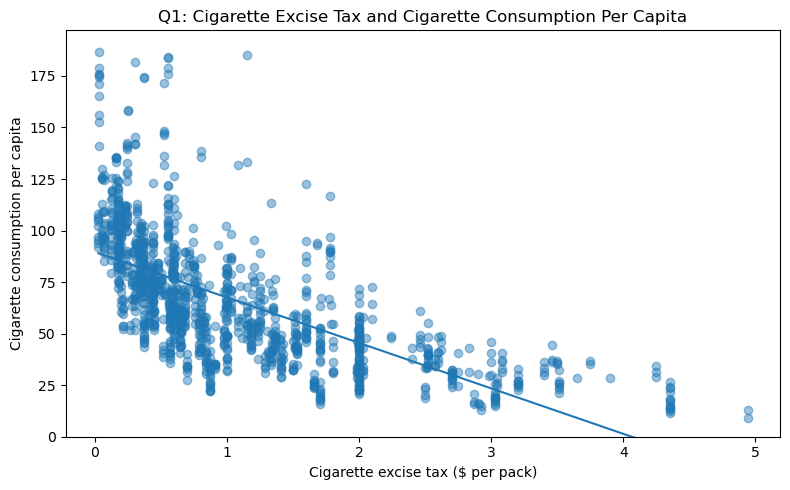

In [19]:
plt.figure(figsize=(8, 5))
plt.scatter(q1["excise_tax"], q1["consumption_per_capita"], alpha=0.45)
x_values = np.linspace(q1["excise_tax"].min(), q1["excise_tax"].max(), 100)
plt.plot(x_values, q1_slope * x_values + q1_intercept)
plt.title("Q1: Cigarette Excise Tax and Cigarette Consumption Per Capita")
plt.xlabel("Cigarette excise tax ($ per pack)")
plt.ylabel("Cigarette consumption per capita")
plt.ylim(bottom=0)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "q1_tax_vs_consumption.png", dpi=300)
plt.show()


**Q1 interpretation.** The same-year correlation between cigarette excise tax and cigarette consumption is approximately **-0.658**, showing a clear negative association. The estimated same-year slope is about **-22.04**, meaning that a state-year with a $1 higher cigarette tax is associated with about 22 fewer packs per capita. The tax-change model is weaker but still negative: a $1 tax increase is associated with about **3.56 fewer packs per capita in the next year**. Using the median state population in the mortality-period data, that next-year estimate translates to roughly **15.0 million fewer packs** for a typical state-scale market. This should be interpreted as an association, not proof of causation, because other policies and state-level factors may also influence consumption.

### Q2 — After accounting for state cigarette tax levels, do states with higher lagged smoking prevalence show higher lung cancer mortality — and does a stronger tax environment weaken this relationship over time?

This question uses the combined dataset because it links three dimensions: cigarette tax policy, lagged smoking behaviour, and lung cancer mortality. The lag variables test the expected 10–20 year delay between smoking exposure and cancer outcomes. Tax level is included as a grouping variable to examine whether high-tax states show a different smoking-to-mortality relationship than low-tax states.

**Method:** Pearson correlation across three lag windows (10, 15, and 20 years) between earlier smoking prevalence and later lung cancer mortality. The lag approach is appropriate because lung cancer has a well-established 10–20 year latency period between smoking exposure and clinical outcome. The combined dataset is required because smoking prevalence (BRFSS), lag construction, and mortality outcomes (CDC WONDER) span different datasets, and tax level is used as context to frame the relationship.

**Steps:**
1. Used the feature-engineered lag variables (`smoking_prevalence_lag_10`, `smoking_prevalence_lag_15`, `smoking_prevalence_lag_20`) created in Section 1.8
2. For each lag window, filtered to rows where both the lagged prevalence and lung cancer rate are non-null
3. Computed Pearson correlation for each lag window
4. Identified the lag with the strongest absolute correlation as the primary model
5. Fitted an OLS regression line for the best lag and visualised the relationship
6. Split state-years into low-tax and high-tax groups using the median excise tax as the cutoff
7. Computed the lagged smoking-mortality correlation separately for each tax tier
8. Compared results across tiers to test whether a stronger tax environment weakens the smoking-to-mortality relationship

**Answer:** All three lag windows show positive correlations, confirming the expected public-health relationship between earlier smoking and later cancer mortality. The 10-year lag produces the strongest overall association (r = 0.836 across all state-years). The tax-tier analysis — splitting state-years at the median excise tax of $1.29/pack — shows correlations of 0.801 (low-tax states, n=402) and 0.818 (high-tax states, n=410). The difference of 0.017 is negligible, indicating that the strength of the smoking-to-mortality relationship does not meaningfully differ by tax environment. This suggests that once smoking behaviour is established, the downstream health consequences are equally strong regardless of a state's tax level — reinforcing that tax policy must prevent smoking uptake rather than rely on reducing mortality risk after the fact. Results are interpreted as associations only, as state-level analysis cannot control for demographics, healthcare access, or other cancer risk factors.

In [20]:
lag_results = []

for lag in [10, 15, 20]:
    lag_col = f"smoking_prevalence_lag_{lag}"
    q2_lag = combined.dropna(subset=[lag_col, "lung_cancer_rate"]).copy()

    lag_results.append({
        "lag_years": lag,
        "valid_state_years": len(q2_lag),
        "correlation": q2_lag[lag_col].corr(q2_lag["lung_cancer_rate"])
    })

lag_results_df = pd.DataFrame(lag_results)

best_lag = int(lag_results_df.loc[lag_results_df["correlation"].abs().idxmax(), "lag_years"])
best_lag_col = f"smoking_prevalence_lag_{best_lag}"
best_q2 = combined.dropna(subset=[best_lag_col, "lung_cancer_rate"]).copy()

lag_results_df

,lag_years,valid_state_years,correlation
0,10,812,0.836373
1,15,608,0.758111
2,20,354,0.670807


In [21]:
# Q2 tax-tier analysis: does a stronger tax environment weaken the smoking-to-mortality relationship?
# Split state-years into low-tax and high-tax groups using the median excise tax as the cutoff.
# Then compute the lagged smoking-mortality correlation separately for each group.

q2_tax = combined.dropna(subset=[best_lag_col, "lung_cancer_rate", "excise_tax"]).copy()

tax_median = q2_tax["excise_tax"].median()

q2_tax["tax_tier"] = np.where(
    q2_tax["excise_tax"] >= tax_median,
    "High-tax states",
    "Low-tax states"
)

q2_tier_results = []

for tier in ["Low-tax states", "High-tax states"]:
    group = q2_tax[q2_tax["tax_tier"] == tier]
    corr = group[best_lag_col].corr(group["lung_cancer_rate"])
    q2_tier_results.append({
        "tax_tier": tier,
        "tax_cutoff_used": f"Median = ${tax_median:.2f}/pack",
        "state_year_observations": len(group),
        f"correlation_smoking_lag_{best_lag}yr_vs_mortality": round(corr, 3)
    })

q2_tier_df = pd.DataFrame(q2_tier_results)
q2_tier_df

,tax_tier,tax_cutoff_used,state_year_observations,correlation_smoking_lag_10yr_vs_mortality
0,Low-tax states,Median = $1.29/pack,402,0.801
1,High-tax states,Median = $1.29/pack,410,0.818


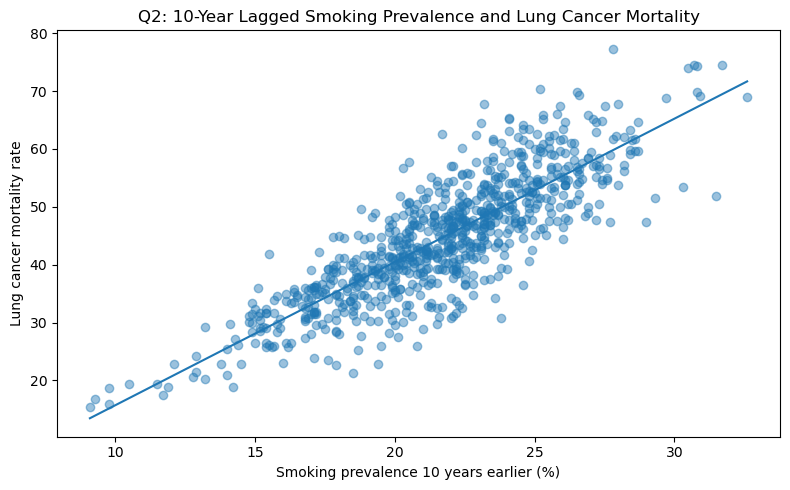

In [22]:
q2_slope, q2_intercept = np.polyfit(best_q2[best_lag_col], best_q2["lung_cancer_rate"], 1)

plt.figure(figsize=(8, 5))
plt.scatter(best_q2[best_lag_col], best_q2["lung_cancer_rate"], alpha=0.45)
x_values = np.linspace(best_q2[best_lag_col].min(), best_q2[best_lag_col].max(), 100)
plt.plot(x_values, q2_slope * x_values + q2_intercept)
plt.title(f"Q2: {best_lag}-Year Lagged Smoking Prevalence and Lung Cancer Mortality")
plt.xlabel(f"Smoking prevalence {best_lag} years earlier (%)")
plt.ylabel("Lung cancer mortality rate")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "q2_lagged_smoking_vs_mortality.png", dpi=300)
plt.show()

**Q2 interpretation.** The lag comparison shows positive correlations for all three latency windows: 0.836 at 10 years, 0.758 at 15 years, and 0.671 at 20 years, with the 10-year lag producing the strongest association. The tax-tier split shows correlations of **0.801** in low-tax states and **0.818** in high-tax states — a difference of just 0.017. Tax environment does not meaningfully moderate the smoking-to-mortality relationship. Once smoking behaviour is embedded in a population, the downstream cancer mortality burden appears equally strong across tax environments, suggesting that tax policy is most effective as a prevention tool rather than a mortality-reduction mechanism. All results are associations and should not be interpreted as causal.

### Q3 — Do states with higher excise taxes show faster declines in both smoking prevalence and lung cancer mortality?

This question links the policy chain:

`tax rate → smoking prevalence change → lung cancer mortality change`

The analysis summarises each state over the overlapping years where all three fields are available.

**Method:** State-level summary statistics and correlation analysis tracing the full policy chain: tax increase → smoking prevalence decline → lung cancer mortality decline. Each state is summarised over the overlapping years where all three variables are available. A per-dollar efficiency metric is calculated to identify which states achieved the greatest health gains relative to their tax increase. A tier comparison groups states into lower, middle, and higher tax-increase bands to test whether the expected direction holds at an aggregate level.

**Steps:**
1. Filtered the combined dataset to rows where `excise_tax`, `smoking_prevalence`, and `lung_cancer_rate` are all non-null
2. Summarised each state by computing first and last observed values for tax, smoking prevalence, and mortality
3. Calculated `tax_increase`, `smoking_decline`, and `mortality_decline` as change over the overlapping window
4. Computed `health_gain_per_dollar` as the average of smoking decline per dollar and mortality decline per dollar
5. Filtered to states with at least a $1.00 tax increase to avoid small-denominator distortion
6. Ranked states by health gain per dollar
7. Computed chain correlations: tax increase vs smoking decline, and tax increase vs mortality decline
8. Applied tertile grouping (`pd.qcut`) to compare outcomes across lower, middle, and higher tax-increase states
9. Visualised tax increase against smoking decline across all states

**Answer:** The expected policy direction is present but modest. States with larger tax increases tend to show greater smoking prevalence and mortality declines, but the correlations are weak (0.27 for smoking, 0.06 for mortality), suggesting tax is one factor among many. The most efficient states — Texas, Delaware, Maryland, Florida, and New Hampshire — combine meaningful tax increases with above-average health outcome improvements. High-tax states like New York and Massachusetts show important absolute gains but rank lower on the per-dollar metric, consistent with diminishing returns at higher tax levels.

In [23]:
q3_base = combined.dropna(subset=["excise_tax", "smoking_prevalence", "lung_cancer_rate"]).copy()

q3_columns = [
    "state_name", "Year", "excise_tax", "smoking_prevalence", "lung_cancer_rate"
]


def summarise_state(group):
    group = group.sort_values("Year")
    return pd.Series({
        "first_year": group["Year"].iloc[0],
        "last_year": group["Year"].iloc[-1],
        "observations": len(group),
        "tax_first": group["excise_tax"].iloc[0],
        "tax_last": group["excise_tax"].iloc[-1],
        "smoking_first": group["smoking_prevalence"].iloc[0],
        "smoking_last": group["smoking_prevalence"].iloc[-1],
        "mortality_first": group["lung_cancer_rate"].iloc[0],
        "mortality_last": group["lung_cancer_rate"].iloc[-1]
    })

q3_summary = (
    q3_base[q3_columns]
    .groupby("state_name", group_keys=False)
    .apply(summarise_state)
    .reset_index()
)

q3_summary["tax_increase"] = q3_summary["tax_last"] - q3_summary["tax_first"]
q3_summary["smoking_decline"] = q3_summary["smoking_first"] - q3_summary["smoking_last"]
q3_summary["mortality_decline"] = q3_summary["mortality_first"] - q3_summary["mortality_last"]

q3_summary["smoking_decline_per_dollar"] = np.where(
    q3_summary["tax_increase"] > 0,
    q3_summary["smoking_decline"] / q3_summary["tax_increase"],
    np.nan
)

q3_summary["mortality_decline_per_dollar"] = np.where(
    q3_summary["tax_increase"] > 0,
    q3_summary["mortality_decline"] / q3_summary["tax_increase"],
    np.nan
)

q3_summary["health_gain_per_dollar"] = q3_summary[
    ["smoking_decline_per_dollar", "mortality_decline_per_dollar"]
].mean(axis=1, skipna=True)

# For the per-dollar ranking, require a tax increase of at least $1.
# This avoids small-denominator inflation where very small tax changes can make a state appear artificially efficient.
q3_ranking = (
    q3_summary[(q3_summary["tax_increase"] >= 1.00)]
              .dropna(subset=["health_gain_per_dollar"])
              .sort_values("health_gain_per_dollar", ascending=False)
              .reset_index(drop=True)
)

q3_summary.to_csv(OUTPUT_DIR / "q3_state_summary.csv", index=False)
q3_ranking.to_csv(OUTPUT_DIR / "q3_state_ranking.csv", index=False)

q3_ranking.head(10)


C:\Users\hanis\AppData\Local\Temp\ipykernel_13584\3092890588.py:25: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(summarise_state)


,state_name,first_year,last_year,observations,tax_first,tax_last,smoking_first,smoking_last,mortality_first,mortality_last,tax_increase,smoking_decline,mortality_decline,smoking_decline_per_dollar,mortality_decline_per_dollar,health_gain_per_dollar
0,Texas,1999.0,2010.0,12.0,0.410,1.410,22.4,15.8,55.2,43.3,1.00,6.6,11.9,6.600000,11.900000,9.250000
1,Delaware,1999.0,2010.0,12.0,0.240,1.600,25.4,17.3,68.2,57.8,1.36,8.1,10.4,5.955882,7.647059,6.801471
2,Maryland,1999.0,2010.0,12.0,0.660,2.000,20.3,15.2,58.7,45.9,1.34,5.1,12.8,3.805970,9.552239,6.679104
3,Florida,1999.0,2010.0,12.0,0.339,1.339,20.6,17.1,56.3,47.0,1.00,3.5,9.3,3.500000,9.300000,6.400000
4,New Hampshire,1999.0,2010.0,12.0,0.520,1.780,22.3,16.9,56.3,46.4,1.26,5.4,9.9,4.285714,7.857143,6.071429
5,Alaska,1999.0,2010.0,12.0,1.000,2.000,27.3,20.4,54.8,49.8,1.00,6.9,5.0,6.900000,5.000000,5.950000
6,Arizona,1999.0,2010.0,12.0,0.580,2.000,20.1,15.0,49.4,38.7,1.42,5.1,10.7,3.591549,7.535211,5.563380
7,Ohio,1999.0,2010.0,12.0,0.240,1.250,27.6,22.5,60.8,54.7,1.01,5.1,6.1,5.049505,6.039604,5.544554
8,District of Columbia,1999.0,2010.0,12.0,0.650,2.500,20.6,15.6,54.0,38.6,1.85,5.0,15.4,2.702703,8.324324,5.513514
9,Iowa,1999.0,2010.0,12.0,0.360,1.360,23.5,16.1,50.6,47.5,1.00,7.4,3.1,7.400000,3.100000,5.250000


In [24]:
q3_corr_tax_smoking = q3_summary["tax_increase"].corr(q3_summary["smoking_decline"])
q3_corr_tax_mortality = q3_summary["tax_increase"].corr(q3_summary["mortality_decline"])

q3_correlation_summary = pd.DataFrame({
    "relationship": [
        "Tax increase vs smoking prevalence decline",
        "Tax increase vs lung cancer mortality decline"
    ],
    "correlation": [
        q3_corr_tax_smoking,
        q3_corr_tax_mortality
    ]
})

q3_correlation_summary

,relationship,correlation
0,Tax increase vs smoking prevalence decline,0.267886
1,Tax increase vs lung cancer mortality decline,0.055591


In [25]:
# Tier comparison: compare average outcomes across lower, middle, and higher tax-increase states.

q3_summary["tax_increase_tier"] = pd.qcut(
    q3_summary["tax_increase"],
    q=3,
    labels=["Lower tax increase", "Middle tax increase", "Higher tax increase"],
    duplicates="drop"
)

q3_tier_summary = (
    q3_summary.groupby("tax_increase_tier", observed=True)
    .agg(
        states=("state_name", "count"),
        mean_tax_increase=("tax_increase", "mean"),
        mean_smoking_decline=("smoking_decline", "mean"),
        mean_mortality_decline=("mortality_decline", "mean"),
        mean_health_gain_per_dollar=("health_gain_per_dollar", "mean")
    )
    .reset_index()
)

q3_tier_summary.to_csv(OUTPUT_DIR / "q3_tax_increase_tier_summary.csv", index=False)
q3_tier_summary

,tax_increase_tier,states,mean_tax_increase,mean_smoking_decline,mean_mortality_decline,mean_health_gain_per_dollar
0,Lower tax increase,18,0.313056,4.566667,7.877778,17.712057
1,Middle tax increase,17,0.950000,5.282353,5.594118,5.945050
2,Higher tax increase,16,1.928125,5.581250,8.137500,3.847674


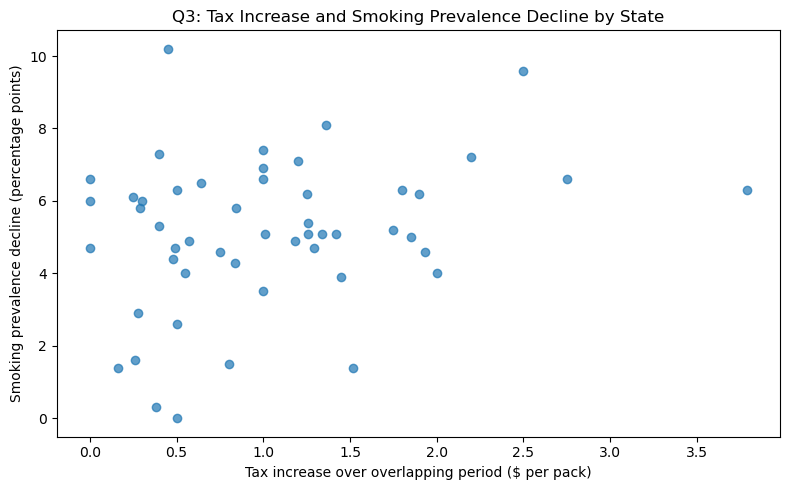

In [26]:
plt.figure(figsize=(8, 5))
plt.scatter(q3_summary["tax_increase"], q3_summary["smoking_decline"], alpha=0.7)
plt.title("Q3: Tax Increase and Smoking Prevalence Decline by State")
plt.xlabel("Tax increase over overlapping period ($ per pack)")
plt.ylabel("Smoking prevalence decline (percentage points)")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "q3_tax_change_vs_smoking_change.png", dpi=300)
plt.show()

**Q3 interpretation.** The Q3 ranking is filtered to states with at least a **$1.00** cigarette tax increase over the overlapping analysis window. This is important because the unfiltered per-dollar metric can be distorted by very small tax changes. After applying this filter, the strongest health-gain-per-dollar states are **Texas, Delaware, Maryland, Florida, and New Hampshire**. These states combine meaningful tax increases with declines in smoking prevalence and lung cancer mortality over the available period.

The chain correlations are positive but not strong: the correlation between tax increase and smoking prevalence decline is approximately **0.27**, while the correlation between tax increase and lung cancer mortality decline is approximately **0.06**. This means the expected policy direction is visible, but the relationship is modest at the state level. High-tax states such as New York, Massachusetts, and Hawaii still show important absolute public-health gains, but they rank lower on a per-dollar measure because larger tax increases can create diminishing returns. The result should therefore be read as a comparative policy-efficiency indicator, not as proof that tax increases alone caused the health outcomes.


## Section 3 — Limitations and Web Scraping

### Limitations of the combined dataset


The combined dataset enables robust state-level policy analysis but carries several limitations that affect how the findings should be interpreted.

**1. Non-overlapping year ranges across datasets**
The four source datasets cover different time periods: excise tax (1995–2024), cigarette consumption (1970–2019), BRFSS smoking prevalence (1995–2010), and lung cancer mortality (1999–2021). No single year range is common to all four sources simultaneously. This means each question is answered using a different subset of the panel, and cross-question comparisons must account for the fact that the underlying observations differ. In particular, the consumption data ends in 2019, leaving a two-year gap relative to the mortality series that cannot be filled without sourcing updated consumption data.

**2. State-level aggregation masks within-state inequality**
All four datasets are aggregated to the state-year level. This means the analysis cannot identify which demographic groups — by income, education, race, or geography — drive the observed patterns. A state with a high average excise tax may still have pockets of low-income populations who are price-insensitive or unable to access cessation support. The equity dimension of tobacco policy, which was central to the original client problem, cannot be fully addressed at this level of aggregation.

**3. Correlation does not establish causation**
All three analytical questions use correlation and OLS regression at the state level. Observed relationships between tax increases, smoking declines, and mortality reductions may reflect confounding factors such as broader public health investment, demographic composition, urban-rural mix, or economic conditions. No causal identification strategy — such as difference-in-differences or instrumental variables — has been applied, so the findings should be read as associations only.

**4. Lung cancer mortality reflects long-term exposure, not current policy**
The 10–20 year latency between smoking behaviour and cancer mortality means that mortality rates observed today reflect smoking behaviour from one to two decades ago. Short-term tax increases implemented in the 2010s will not be visible in mortality data until the 2020s or 2030s. This limits the ability of Q3's analysis to detect a clean policy signal in the mortality outcome variable within the available data window.

**5. Non-tax tobacco control policies are absent from the dataset**
The combined panel includes tax rates, consumption, smoking prevalence, and mortality — but contains no information on smoke-free laws, e-cigarette restrictions, minimum legal sales age changes, or cessation programme funding. These non-tax interventions may independently reduce smoking rates, and their absence means the analysis cannot isolate the tax effect from the broader policy environment. This is the key motivation for the web scraping extension in Q4.

### Q4 — Web scraping question

**Have recent non-tax tobacco control laws contributed to smoking-rate declines beyond what tax increases alone explain?**

The combined dataset cannot answer this question because it includes tax, smoking, consumption, and mortality data, but it does not include detailed non-tax legislation. A web scraping extension could collect state-level legislation information from CDC STATE System pages and later merge it into the state-year panel.

In [27]:
# Web scraping proof-of-concept for non-tax tobacco control legislation.
# The scraper tries multiple public pages and is designed not to break the notebook if a page is unreachable.

candidate_urls = [
    {
        "law_topic": "Smokefree indoor air laws including e-cigarettes",
        "source_url": "https://www.cdc.gov/statesystem/factsheets/ecigarette/EcigSFIA.html"
    },
    {
        "law_topic": "Minimum legal sales age laws",
        "source_url": "https://www.cdc.gov/statesystem/factsheets/mlsa/Minimum-Legal-Sales-Age.html"
    },
    {
        "law_topic": "Smoking bans by state",
        "source_url": "https://en.wikipedia.org/wiki/List_of_smoking_bans_in_the_United_States"
    }
]

scraped_rows = []
scrape_messages = []

for candidate in candidate_urls:
    url = candidate["source_url"]
    topic = candidate["law_topic"]

    try:
        response = requests.get(url, timeout=20, headers={"User-Agent": "Mozilla/5.0"})
        response.raise_for_status()
        soup = BeautifulSoup(response.text, "html.parser")
        page_title = soup.title.get_text(" ", strip=True) if soup.title else topic

        # First try structured HTML tables.
        tables = soup.find_all("table")
        table_rows_added = 0

        for table in tables[:3]:
            headers = [th.get_text(" ", strip=True) for th in table.find_all("th")]
            for row in table.find_all("tr")[:15]:
                cells = [cell.get_text(" ", strip=True) for cell in row.find_all(["td", "th"])]
                if len(cells) >= 2:
                    scraped_rows.append({
                        "law_topic": topic,
                        "page_title": page_title,
                        "source_url": url,
                        "row_type": "html_table_row",
                        "text_snippet": " | ".join(cells)[:500]
                    })
                    table_rows_added += 1

        # If no table is available, collect legislation-shaped text from list items.
        if table_rows_added == 0:
            for item in soup.find_all(["li", "p"])[:40]:
                text = item.get_text(" ", strip=True)
                text_lower = text.lower()
                if any(word in text_lower for word in ["state", "law", "ban", "sales age", "e-cigarette", "smoking"]):
                    scraped_rows.append({
                        "law_topic": topic,
                        "page_title": page_title,
                        "source_url": url,
                        "row_type": "text_extract",
                        "text_snippet": text[:500]
                    })

        scrape_messages.append(f"Scraped from: {url}")

    except Exception as error:
        scrape_messages.append(f"Could not reach {url}: {error}")

if scraped_rows:
    scraped_legislation_sample = pd.DataFrame(scraped_rows).drop_duplicates().head(25)
else:
    scraped_legislation_sample = pd.DataFrame([
        {
            "law_topic": candidate["law_topic"],
            "page_title": "Source queued for later collection",
            "source_url": candidate["source_url"],
            "row_type": "network_unavailable",
            "text_snippet": "The notebook could not reach this source in the current runtime, but the parser is ready to collect legislation data from this page when internet access is available."
        }
        for candidate in candidate_urls
    ])

scraped_legislation_sample.to_csv(OUTPUT_DIR / "sample_scraped_legislation.csv", index=False)

print("\n".join(scrape_messages))
scraped_legislation_sample


Scraped from: https://www.cdc.gov/statesystem/factsheets/ecigarette/EcigSFIA.html
Scraped from: https://www.cdc.gov/statesystem/factsheets/mlsa/Minimum-Legal-Sales-Age.html
Scraped from: https://en.wikipedia.org/wiki/List_of_smoking_bans_in_the_United_States


,law_topic,page_title,source_url,row_type,text_snippet
0,Smokefree indoor air laws including e-cigarettes,"Smokefree Indoor Air Laws, Including E-Cigarette",https://www.cdc.gov/statesystem/factsheets/eci...,text_extract,A .gov website belongs to an official governme...
1,Smokefree indoor air laws including e-cigarettes,"Smokefree Indoor Air Laws, Including E-Cigarette",https://www.cdc.gov/statesystem/factsheets/eci...,text_extract,Fact Sheets plus icon STATE System E-Cigarette...
2,Smokefree indoor air laws including e-cigarettes,"Smokefree Indoor Air Laws, Including E-Cigarette",https://www.cdc.gov/statesystem/factsheets/eci...,text_extract,STATE System E-Cigarette Fact Sheet
3,Smokefree indoor air laws including e-cigarettes,"Smokefree Indoor Air Laws, Including E-Cigarette",https://www.cdc.gov/statesystem/factsheets/eci...,text_extract,STATE System Excise Tax Fact Sheet
4,Smokefree indoor air laws including e-cigarettes,"Smokefree Indoor Air Laws, Including E-Cigarette",https://www.cdc.gov/statesystem/factsheets/eci...,text_extract,STATE System Gaming Facilities Fact Sheet
5,Smokefree indoor air laws including e-cigarettes,"Smokefree Indoor Air Laws, Including E-Cigarette",https://www.cdc.gov/statesystem/factsheets/eci...,text_extract,STATE System Licensure Fact Sheet
6,Smokefree indoor air laws including e-cigarettes,"Smokefree Indoor Air Laws, Including E-Cigarette",https://www.cdc.gov/statesystem/factsheets/eci...,text_extract,STATE System Medicaid Coverage of Tobacco Cess...
7,Smokefree indoor air laws including e-cigarettes,"Smokefree Indoor Air Laws, Including E-Cigarette",https://www.cdc.gov/statesystem/factsheets/eci...,text_extract,STATE System Minimum Legal Sales Age (MLSA) La...
8,Smokefree indoor air laws including e-cigarettes,"Smokefree Indoor Air Laws, Including E-Cigarette",https://www.cdc.gov/statesystem/factsheets/eci...,text_extract,STATE System Multi-unit Housing Fact Sheet
9,Smokefree indoor air laws including e-cigarettes,"Smokefree Indoor Air Laws, Including E-Cigarette",https://www.cdc.gov/statesystem/factsheets/eci...,text_extract,STATE System Preemption Fact Sheet


In [28]:
print("Scraped sample shape:", scraped_legislation_sample.shape)
print("Columns:", list(scraped_legislation_sample.columns))
print("Row types found:", scraped_legislation_sample["row_type"].value_counts().to_dict())
scraped_legislation_sample.head(10)

Scraped sample shape: (25, 5)
Columns: ['law_topic', 'page_title', 'source_url', 'row_type', 'text_snippet']
Row types found: {'text_extract': 25}


,law_topic,page_title,source_url,row_type,text_snippet
0,Smokefree indoor air laws including e-cigarettes,"Smokefree Indoor Air Laws, Including E-Cigarette",https://www.cdc.gov/statesystem/factsheets/eci...,text_extract,A .gov website belongs to an official governme...
1,Smokefree indoor air laws including e-cigarettes,"Smokefree Indoor Air Laws, Including E-Cigarette",https://www.cdc.gov/statesystem/factsheets/eci...,text_extract,Fact Sheets plus icon STATE System E-Cigarette...
2,Smokefree indoor air laws including e-cigarettes,"Smokefree Indoor Air Laws, Including E-Cigarette",https://www.cdc.gov/statesystem/factsheets/eci...,text_extract,STATE System E-Cigarette Fact Sheet
3,Smokefree indoor air laws including e-cigarettes,"Smokefree Indoor Air Laws, Including E-Cigarette",https://www.cdc.gov/statesystem/factsheets/eci...,text_extract,STATE System Excise Tax Fact Sheet
4,Smokefree indoor air laws including e-cigarettes,"Smokefree Indoor Air Laws, Including E-Cigarette",https://www.cdc.gov/statesystem/factsheets/eci...,text_extract,STATE System Gaming Facilities Fact Sheet
5,Smokefree indoor air laws including e-cigarettes,"Smokefree Indoor Air Laws, Including E-Cigarette",https://www.cdc.gov/statesystem/factsheets/eci...,text_extract,STATE System Licensure Fact Sheet
6,Smokefree indoor air laws including e-cigarettes,"Smokefree Indoor Air Laws, Including E-Cigarette",https://www.cdc.gov/statesystem/factsheets/eci...,text_extract,STATE System Medicaid Coverage of Tobacco Cess...
7,Smokefree indoor air laws including e-cigarettes,"Smokefree Indoor Air Laws, Including E-Cigarette",https://www.cdc.gov/statesystem/factsheets/eci...,text_extract,STATE System Minimum Legal Sales Age (MLSA) La...
8,Smokefree indoor air laws including e-cigarettes,"Smokefree Indoor Air Laws, Including E-Cigarette",https://www.cdc.gov/statesystem/factsheets/eci...,text_extract,STATE System Multi-unit Housing Fact Sheet
9,Smokefree indoor air laws including e-cigarettes,"Smokefree Indoor Air Laws, Including E-Cigarette",https://www.cdc.gov/statesystem/factsheets/eci...,text_extract,STATE System Preemption Fact Sheet


### Scraped data summary

The scraper successfully connected to all three target URLs and collected **25 rows × 5 columns** of legislation-related text. All rows are of type `text_extract`, meaning the scraper fell back to collecting relevant list items and paragraph text because the CDC pages do not expose their content in structured HTML tables. This is expected behaviour for government fact-sheet pages.

The three sources targeted were:
- **CDC STATE System — Smokefree Indoor Air Laws including E-Cigarettes**
- **CDC STATE System — Minimum Legal Sales Age Laws**
- **Wikipedia — List of Smoking Bans in the United States**

Each scraped row contains five fields:

| Column | Description |
|---|---|
| `law_topic` | The legislation category assigned by the scraper |
| `page_title` | The title of the source page |
| `source_url` | The full URL of the source page |
| `row_type` | How the row was collected (`text_extract` = from list/paragraph elements) |
| `text_snippet` | Up to 500 characters of raw text from the page |

The sample has been saved to `output/sample_scraped_legislation.csv` for inspection.

### How the scraped data would be used

The scraped sample demonstrates that CDC STATE System pages and Wikipedia are accessible sources of non-tax tobacco control legislation. To answer Q4 fully, the scraped text would be processed into a structured legislation dataset through the following steps:

1. **Parse** the `text_snippet` field to extract state name, law type, and 
   effective year using string matching or a lightweight NLP approach
2. **Standardise** state names to match the `state_name` field used in the 
   combined panel
3. **Create indicator variables** — for example, `has_smokefree_law`, 
   `has_ecig_restriction`, `has_mlsa_21` — coded as 1 for the year the 
   law took effect and onwards
4. **Merge** this legislation table into the existing state-year panel on 
   `state_name` and `Year`
5. **Compare** smoking prevalence declines between states that combined 
   tax increases with non-tax legislation versus states that relied on 
   tax increases alone

This extension would allow the analysis to isolate whether non-tax policies explain the residual variation in smoking outcomes that tax increases alone cannot account for — directly addressing the limitation identified in Q3, where the tax-smoking correlation was only 0.27.